<div style="text-align: right"><img src="https://www.haskoning.com/-/media/project/common/haskoning-logo.svg" align="right" valign="top" style="margin: 0px 0px 10px 10px;" width=300></div>

<font size=20>D-Hydro to ISG</font>
<a class="anchor" id="stap0"></a>

Dhydro2ISG is a Python package that can extract data from a D-Hydro model to input for a groundwater model in ISG format. The package is developed by Haskoning and made open-source with financial support of waterboard De Dommel. 

#### Workflow 
The workflow to create an ISG file based on D-Hydro model is as follows:
1. Define input, e.g. period from which the water level is extracted
2. Extract data from D-Hydro model 
3. Export to ISG

Optionally you can:
- Export the standardized data to shape, edit the data in GIS and import it again
- Import ISG files

#### ISG Support
The tool creates an ISG file without support for surface-flow routing (ASFR=0). This ISG file contains the following parameters:

| Parameter       | Description                                                            | Source |
|-------------|------------------------------------------------------------------------|-----|
| Water level | The water level at the calculation node for defined period                               | D-Hydro model |
| Bottom level| The bottom level at the calculation node                               | D-Hydro model |
| Resistance  | The resistance of the river bed at the calculation node (days)                                | Manual input |
| Inf.factor  | The infiltration factor at the calculation node (-)                       | Manual input |
| mrc  | Manning’s Resistance Coefficient MRC for the cross-section (-)                       | Manual input |

 

Q-H relationships and structures are not supported. 


#### Notes
Note that the code is tested for a limited amount of D-Hydro models and therefore it is required to validate the output before using it. The code is tested for D-Hydro versions XX, XX, 2025.01 and 2025.03. 

The package is open-source so if you miss functionality you can create a new branch on github and propose a solution. If you experience a bug you can create an issue in github and preferable also propose a solution.  

This tool depends on hydrolib-core. If the model version is not supported by hydrolib core this could raise an error. This is a known issue. 

Only cross sections with YZ-profiles are supported.


In [2]:
import os
import pyproj
import plotly.graph_objects as go
from dhydro2isg.dhydro2isg import dhydro_to_stf
from dhydro2isg.stf import STF

## Input
The water level is aggregated for the defined period. If you aggragate the mean value, the average water level is extracted for the defined period. In the output this value is written to the start and end date of this period.

For the water levels the map.nc file is used (not the his file). The timestep of this output file must be small enough to describe the required detail (usually the his file has a smaller timestep).

In [3]:
path_dhydro_model = r"data/Haskoning_example.dsproj_data/Haskoning_example" # Path to the D-HYDRO model folder (use forward slash `/` if you run on Binder)
output_folder = r"" # Path to the output folder where the ISG file will be saved

start_period = "2026-01-03" # format: YYYY-MM-DD
end_period = "2026-01-05" # format: YYYY-MM-DD
aggregation_method = "mean" # Method to aggregate D-Hydro map data over the specified period. Options: "mean", "max", "min", "sum"

# Uniform parameters for all calculation points and segments
resistance = 1 #  Uniform Resistance of the riverbed (days).
infiltration = 0.3 # Uniform infiltration coefficient for all calculation points
mrc = 0.02 # Uniform manning resistance coefficient for all segments

# Change the relative paths for the following D-Hydro files only if they are not in the default location
relpath_network_nc = 'input/FlowFM_net.nc' 
relpath_map_nc = 'output/Haskoning_example_map.nc' 
relpath_crossloc_ini = 'input/crsloc.ini' 
relpath_crossdef_ini = 'input/crsdef.ini' 

## Extract data from D-Hydro model 
In this step the relevant data is extracted from the D-Hydro model and converted to a standardized table format (STF). For the resistance, infiltration and manning roughness a uniform value is applied.

In [4]:
stf = dhydro_to_stf(dhydro_folder=path_dhydro_model,
                    start_time=start_period,
                    end_time=end_period,
                    resistance=resistance,
                    infiltration=infiltration,
                    mrc=mrc,
                    aggregation_method=aggregation_method,
                    epsg=28992,
                    output_name="dhydro_to_isg",
                    relpath_network_nc=relpath_network_nc,
                    relpath_map_nc=relpath_map_nc,
                    relpath_crossloc_ini=relpath_crossloc_ini,
                    relpath_crossdef_ini=relpath_crossdef_ini,
                    )

import succeeded


You can discover (and edit if you want) the extracted data in the SFT with the following functions:
- `stf.segments`
- `stf.locations`
- `stf.calculation_points`
- `stf.cross_sections`

For example:

<Axes: >

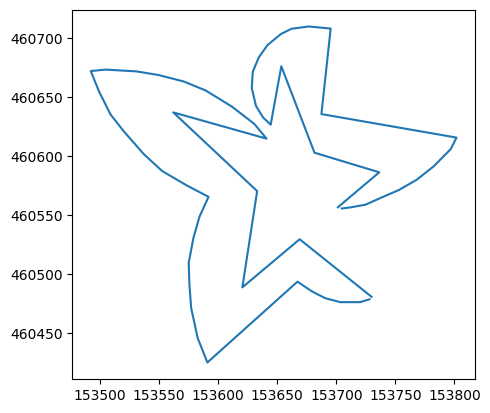

In [5]:
stf.segments.plot()

#### Visulisation of the water levels

In [6]:
df = stf.locations.join(stf.calculation_points)
df = df.xs(start_period, level=2)
filtered = df.droplevel(1)

# try to get coordinates from common columns or geometry
if {'x', 'y'}.issubset(filtered.columns):
    lon_col, lat_col = 'x', 'y'
elif 'geometry' in filtered.columns:
    filtered['x'] = filtered['geometry'].apply(lambda g: getattr(g, 'x', None))
    filtered['y'] = filtered['geometry'].apply(lambda g: getattr(g, 'y', None))
    lon_col, lat_col = 'x', 'y'
else:
    raise RuntimeError("No coordinate columns ('x','y' or 'geometry') found in stf.locations")

# Transform coordinates from EPSG:28992 (RD New) to EPSG:4326 (WGS84) for Mapbox
transformer = pyproj.Transformer.from_crs(28992, 4326, always_xy=True)
filtered['lon_wgs84'], filtered['lat_wgs84'] = transformer.transform(filtered['x'].values, filtered['y'].values)

fig = go.Figure(data=go.Scattermapbox(
    lon=filtered['lon_wgs84'],
    lat=filtered['lat_wgs84'],
    mode='markers',
    marker=dict(
        size=8,
        color=filtered['wlvl'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Water Level")
    ),
    text=filtered.index,
    customdata=filtered[['wlvl', 'btml', 'resis', 'inff']].values,
    hovertemplate='<b>%{text}</b><br>Water Level: %{customdata[0]:.3f}<br>Bed level: %{customdata[1]:.3f}<br>Resistance: %{customdata[2]:.3f}<br>Infiltration: %{customdata[3]:.3f}<extra></extra>'
))

fig.update_layout(
    mapbox=dict(
        style='open-street-map',
        center=dict(lon=filtered['lon_wgs84'].mean(), lat=filtered['lat_wgs84'].mean()),
        zoom=12
    ),
    title=f"Water levels ({aggregation_method}) at the calculation points between {start_period} and {end_period}",
    height=600,
    hovermode='closest'
)

fig.show()

## Export to ISG
Export the converted data to ISG format

In [ ]:
stf.export_to_isg(export_folder=output_folder, filename='test_output_isg')

Validation tables successful
no structures in dataframe


PermissionError: [Errno 13] Permission denied: '/test_output_isg2.ISG'

## Additional functionality

### Export to and import from shapes
You can export the converted data to shapes and load it again. With this option is it possible to edit the data in GIS.  

**Export to shapes**

In [9]:
export_folder = os.path.join(output_folder, 'shape_export') # Path where the shape files will be saved
filename_export = 'stf_export' # Name of the shape file without extension

stf.export_to_shape(export_folder=export_folder, filename=filename_export)

Export completed


**Import from shapes**

In [ ]:
updated_STF = STF() # Create a new STF object
updated_STF.import_from_shape(import_folder=export_folder, prefix_filename=filename_export) # Import the shape files into the new STF object. Change the export folder and filename as needed.

### Import from ISG
It is also possible to load an ISG. This will overwrite the tables in memory. Therefore it is adviced to create a new empty STF object.

In [ ]:
filepath_isg = output_folder # path to the folder where the ISG files are saved

other_stf=STF()
other_stf.import_isg(filepath_isg)